# FinPilot AI Fraud Detection

## Objective

Develop an AI-powered Fraud Detection System capable of identifying suspicious banking transactions using Machine Learning.

---

### Dataset

PaySim Mobile Money Fraud Detection Dataset

---

### Machine Learning Pipeline

- Exploratory Data Analysis
- Feature Engineering
- Data Balancing using SMOTE
- Random Forest Classification
- Hyperparameter Optimization
- Threshold Optimization
- Model Evaluation

---

### Deployment

- FastAPI
- Spring Boot
- React



In [ ]:
# Install Required Libraries

!pip install -q kagglehub
!pip install -q imbalanced-learn
!pip install -q joblib
!pip install -q xgboost

In [ ]:
# Ignore warnings

import warnings
warnings.filterwarnings("ignore")

In [ ]:
# Core Libraries

import os
import glob
import joblib

import numpy as np
import pandas as pd

In [ ]:
# Visualization

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
plt.rcParams["figure.figsize"] = (10,6)

In [ ]:
# Machine Learning

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV
)

from sklearn.ensemble import RandomForestClassifier

In [ ]:
# Evaluation

from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    roc_auc_score,

    confusion_matrix,

    classification_report,

    roc_curve,

    precision_recall_curve
)

In [ ]:
# Imbalanced Dataset Handling

from imblearn.over_sampling import SMOTE

In [ ]:
# Download Dataset

import kagglehub

dataset_path = kagglehub.dataset_download(
    "ealaxi/paysim1"
)

print(dataset_path)

100%|██████████| 178M/178M [00:02<00:00, 75.0MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/ealaxi/paysim1/versions/2


In [ ]:
# Locate Dataset

csv_files = glob.glob(
    os.path.join(dataset_path, "*.csv")
)

csv_files

['/root/.cache/kagglehub/datasets/ealaxi/paysim1/versions/2/PS_20174392719_1491204439457_log.csv']

In [ ]:
 # Load Dataset

df = pd.read_csv(
    csv_files[0],
    nrows=300000
)

In [ ]:
print("Rows :", df.shape[0])

print("Columns :", df.shape[1])

df.info()

Rows : 300000
Columns : 11
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   step            300000 non-null  int64  
 1   type            300000 non-null  object 
 2   amount          300000 non-null  float64
 3   nameOrig        300000 non-null  object 
 4   oldbalanceOrg   300000 non-null  float64
 5   newbalanceOrig  300000 non-null  float64
 6   nameDest        300000 non-null  object 
 7   oldbalanceDest  300000 non-null  float64
 8   newbalanceDest  300000 non-null  float64
 9   isFraud         300000 non-null  int64  
 10  isFlaggedFraud  300000 non-null  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 25.2+ MB


In [ ]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
step,300000.0,1.144147e+01,2.639757e+00,1.0,10.00,12.000,1.400000e+01,15.00
amount,300000.0,1.761708e+05,3.016055e+05,0.3,12741.25,77699.525,2.314789e+05,10000000.00
oldbalanceOrg,300000.0,8.855676e+05,2.849254e+06,0.0,0.00,18569.000,1.836875e+05,38939424.03
newbalanceOrig,300000.0,9.042820e+05,2.886694e+06,0.0,0.00,0.000,2.214797e+05,38946233.02
oldbalanceDest,300000.0,9.774525e+05,2.369811e+06,0.0,0.00,86166.865,8.571552e+05,41338441.34
newbalanceDest,300000.0,1.196709e+06,2.594207e+06,0.0,0.00,190822.025,1.238132e+06,41383645.15
isFraud,300000.0,6.033333e-04,2.455547e-02,0.0,0.00,0.000,0.000000e+00,1.00
isFlaggedFraud,300000.0,0.000000e+00,0.000000e+00,0.0,0.00,0.000,0.000000e+00,0.00


In [ ]:
df.isnull().sum()

,0
step,0
type,0
amount,0
nameOrig,0
oldbalanceOrg,0
newbalanceOrig,0
nameDest,0
oldbalanceDest,0
newbalanceDest,0
isFraud,0


In [ ]:
df.duplicated().sum()

np.int64(0)

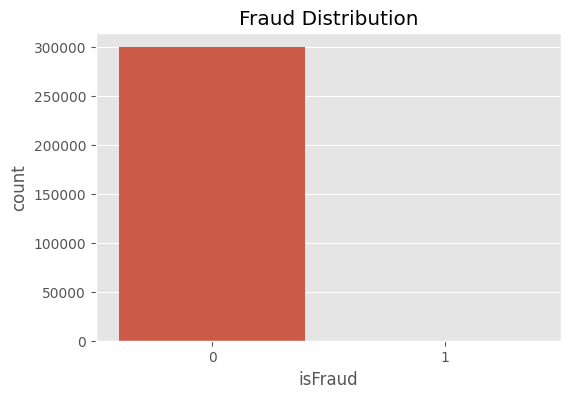

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x=df["isFraud"]
)

plt.title("Fraud Distribution")

plt.show()

In [ ]:
fraud_percent = (
    df["isFraud"]
      .value_counts(normalize=True)
      *100
)

fraud_percent

,proportion
isFraud,
0,99.939667
1,0.060333


Feature Engineering

In [ ]:
# Create Working Copy

data = df.copy()

print(data.shape)

(300000, 11)


In [ ]:
encoder = LabelEncoder()

data["type"] = encoder.fit_transform(data["type"])

encoder.classes_

array(['CASH_IN', 'CASH_OUT', 'DEBIT', 'PAYMENT', 'TRANSFER'],
      dtype=object)

In [ ]:
data["hour"] = data["step"] % 24

data[["step","hour"]].head()

,step,hour
0,1,1
1,1,1
2,1,1
3,1,1
4,1,1


In [ ]:
data["night_transaction"] = (

    (data["hour"] >= 22) |

    (data["hour"] <= 5)

).astype(int)

data["night_transaction"].value_counts()

,count
night_transaction,
0,294496
1,5504


In [ ]:
data["sender_change"] = (

    data["oldbalanceOrg"]

    -

    data["newbalanceOrig"]

)

data["sender_change"].head()

,sender_change
0,9839.64
1,1864.28
2,181.00
3,181.00
4,11668.14


In [ ]:
data["receiver_change"] = (

    data["newbalanceDest"]

    -

    data["oldbalanceDest"]

)

data["receiver_change"].head()

,receiver_change
0,0.0
1,0.0
2,0.0
3,-21182.0
4,0.0


In [ ]:
data["amount_balance_ratio"] = (

    data["amount"]

    /

    (data["oldbalanceOrg"] + 1)

)

data["amount_balance_ratio"].describe()

,amount_balance_ratio
count,3.000000e+05
mean,5.892649e+04
std,1.941103e+05
min,5.012203e-07
25%,1.516685e-01
50%,5.455804e+00
75%,1.204336e+04
max,5.677662e+06


In [ ]:
data["large_transaction"] = (

    data["amount"] > 50000

).astype(int)

data["large_transaction"].value_counts()

,count
large_transaction,
1,166508
0,133492


In [ ]:
data["high_balance_usage"] = (

    data["amount_balance_ratio"] > 0.80

).astype(int)

data["high_balance_usage"].value_counts()

,count
high_balance_usage,
1,189417
0,110583


In [ ]:
data["zero_sender_balance"] = (

    data["oldbalanceOrg"] == 0

).astype(int)

In [ ]:
data["zero_receiver_balance"] = (

    data["oldbalanceDest"] == 0

).astype(int)

In [ ]:
data["suspicious_amount"] = (

    data["amount"] > 10000

).astype(int)

In [ ]:
data["balance_usage_percent"] = (

    data["amount"]

    /

    (data["oldbalanceOrg"] + 1)

) * 100

In [ ]:
new_features = [

    "hour",

    "night_transaction",

    "sender_change",

    "receiver_change",

    "amount_balance_ratio",

    "large_transaction",

    "high_balance_usage",

    "zero_sender_balance",

    "zero_receiver_balance",

    "suspicious_amount",

    "balance_usage_percent"

]

data[new_features].head()

,hour,night_transaction,sender_change,receiver_change,amount_balance_ratio,large_transaction,high_balance_usage,zero_sender_balance,zero_receiver_balance,suspicious_amount,balance_usage_percent
0,1,1,9839.64,0.0,0.057834,0,0,0,1,0,5.783363
1,1,1,1864.28,0.0,0.087731,0,0,0,1,0,8.773082
2,1,1,181.00,0.0,0.994505,0,1,0,1,0,99.450549
3,1,1,181.00,-21182.0,0.994505,0,1,0,0,0,99.450549
4,1,1,11668.14,0.0,0.280788,0,0,0,1,1,28.078787


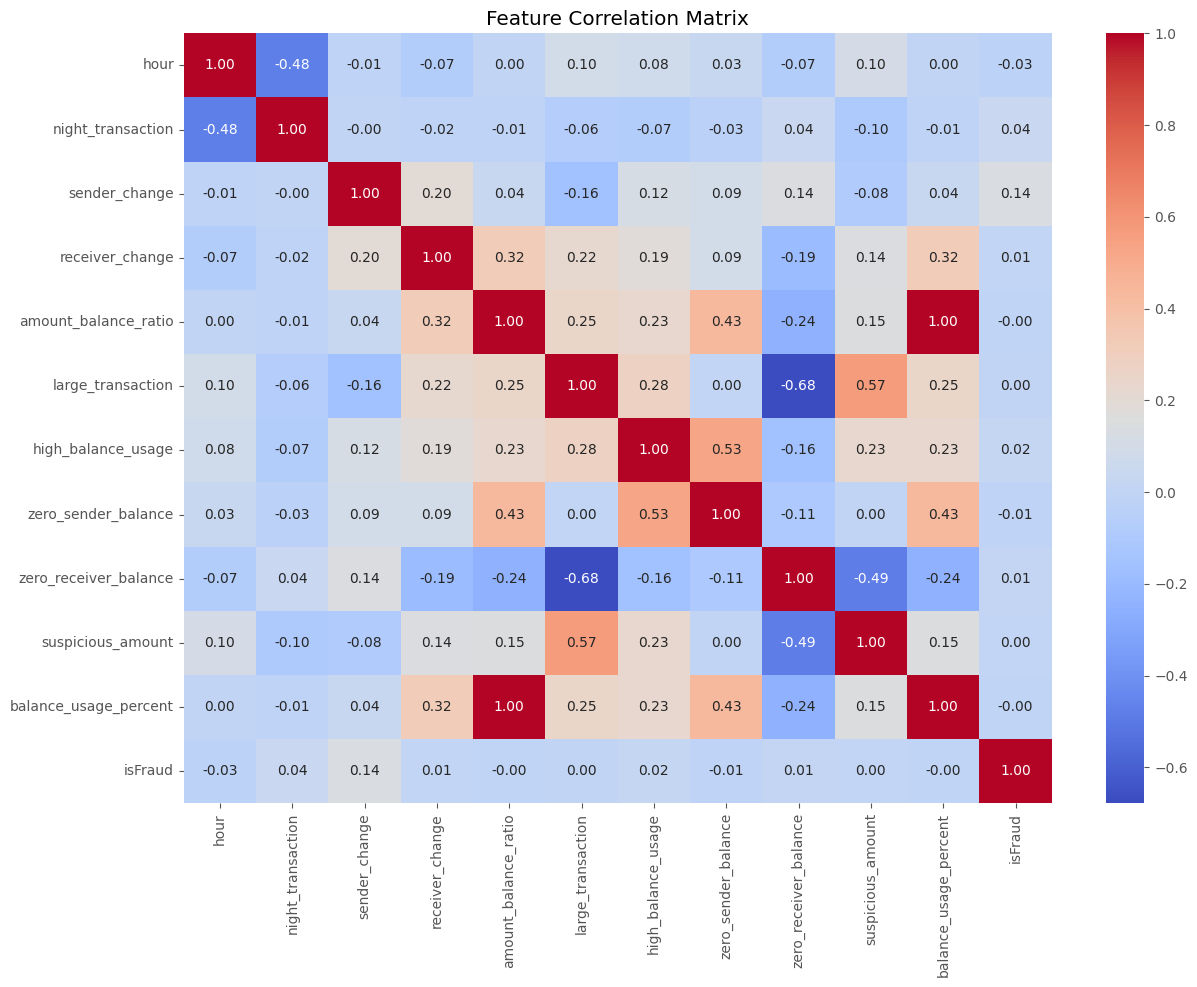

In [ ]:
plt.figure(figsize=(14,10))

corr = data[

    new_features +

    ["isFraud"]

].corr()

sns.heatmap(

    corr,

    annot=True,

    cmap="coolwarm",

    fmt=".2f"

)

plt.title("Feature Correlation Matrix")

plt.show()

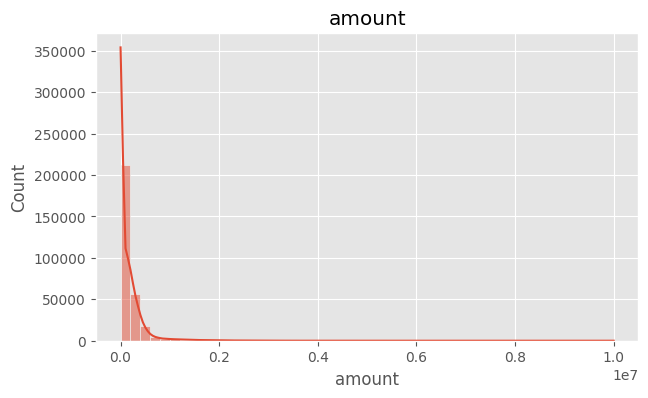

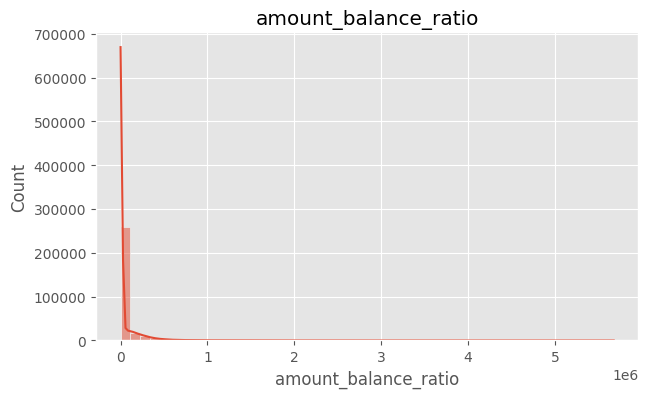

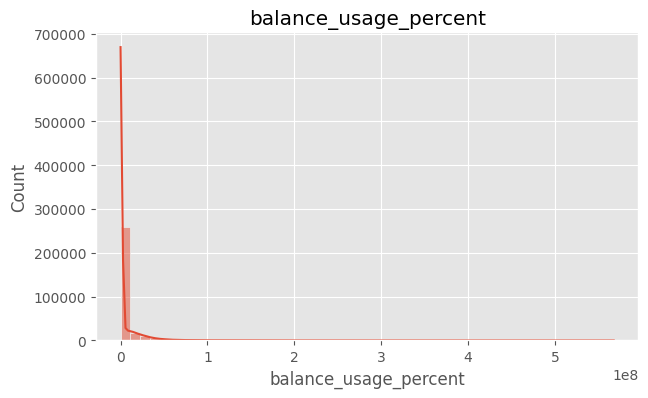

In [ ]:
for column in [

    "amount",

    "amount_balance_ratio",

    "balance_usage_percent"

]:

    plt.figure(figsize=(7,4))

    sns.histplot(

        data[column],

        bins=50,

        kde=True

    )

    plt.title(column)

    plt.show()

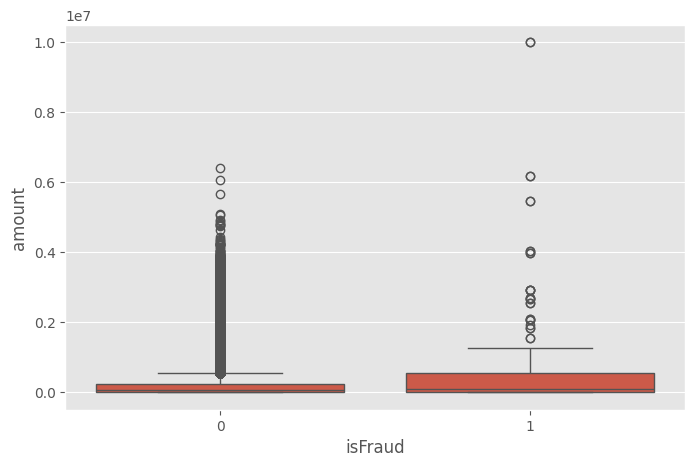

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(

    x="isFraud",

    y="amount",

    data=data

)

plt.show()

Feature Selection

In [ ]:
data.columns.tolist()

['step',
 'type',
 'amount',
 'nameOrig',
 'oldbalanceOrg',
 'newbalanceOrig',
 'nameDest',
 'oldbalanceDest',
 'newbalanceDest',
 'isFraud',
 'isFlaggedFraud',
 'hour',
 'night_transaction',
 'sender_change',
 'receiver_change',
 'amount_balance_ratio',
 'large_transaction',
 'high_balance_usage',
 'zero_sender_balance',
 'zero_receiver_balance',
 'suspicious_amount',
 'balance_usage_percent']

In [ ]:
drop_columns = [

    "nameOrig",
    "nameDest",

    "isFlaggedFraud"

]

data = data.drop(columns=drop_columns)

print(data.shape)

(300000, 19)


In [ ]:
FEATURE_COLUMNS = [

    # Original Features

    "step",

    "type",

    "amount",

    "oldbalanceOrg",

    "newbalanceOrig",

    "oldbalanceDest",

    "newbalanceDest",

    # Engineered Features

    "hour",

    "night_transaction",

    "sender_change",

    "receiver_change",

    "amount_balance_ratio",

    "large_transaction",

    "high_balance_usage",

    "zero_sender_balance",

    "zero_receiver_balance",

    "suspicious_amount",

    "balance_usage_percent"

]

In [ ]:
X = data[FEATURE_COLUMNS]

y = data["isFraud"]

print(X.shape)

print(y.shape)

(300000, 18)
(300000,)


In [ ]:
print(y.value_counts())

print()

print(y.value_counts(normalize=True) * 100)

isFraud
0    299819
1       181
Name: count, dtype: int64

isFraud
0    99.939667
1     0.060333
Name: proportion, dtype: float64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y

)

print(X_train.shape)

print(X_test.shape)

(240000, 18)
(60000, 18)


In [ ]:
smote = SMOTE(

    random_state=42

)

X_train_smote, y_train_smote = smote.fit_resample(

    X_train,

    y_train

)

print("Before")

print(y_train.value_counts())

print()

print("After")

print(y_train_smote.value_counts())

Before
isFraud
0    239855
1       145
Name: count, dtype: int64

After
isFraud
0    239855
1    239855
Name: count, dtype: int64


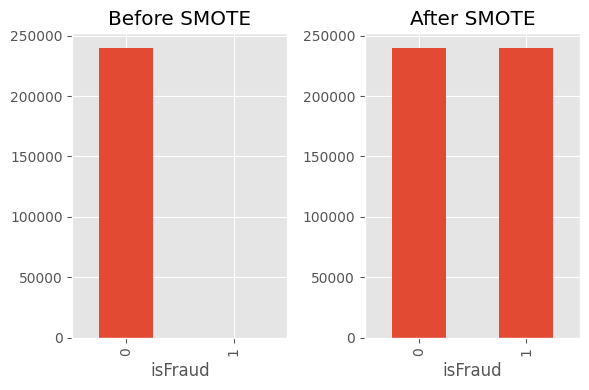

In [ ]:
plt.figure(figsize=(6,4))

plt.subplot(121)

y_train.value_counts().plot(

    kind="bar",

    title="Before SMOTE"

)

plt.subplot(122)

y_train_smote.value_counts().plot(

    kind="bar",

    title="After SMOTE"

)

plt.tight_layout()

plt.show()

In [ ]:
joblib.dump(

    FEATURE_COLUMNS,

    "feature_columns.pkl"

)

['feature_columns.pkl']

In [ ]:
from sklearn.linear_model import LogisticRegression

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

In [ ]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_smote,
    y_train_smote
)

print("Logistic Regression Trained")

Logistic Regression Trained


In [ ]:
lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(
    X_train_smote,
    y_train_smote
)

print("Logistic Regression Trained")

Logistic Regression Trained


In [ ]:
rf = RandomForestClassifier(

    n_estimators=500,

    max_depth=18,

    min_samples_split=5,

    min_samples_leaf=2,

    class_weight="balanced",

    random_state=42,

    n_jobs=-1

)

rf.fit(
    X_train_smote,
    y_train_smote
)

print("Random Forest Trained")

Random Forest Trained


In [ ]:
xgb = XGBClassifier(

    n_estimators=400,

    max_depth=8,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    eval_metric="logloss"

)

xgb.fit(

    X_train_smote,

    y_train_smote

)

print("XGBoost Trained")

XGBoost Trained


In [ ]:
def evaluate_model(model, name):

    pred = model.predict(X_test)

    proba = model.predict_proba(X_test)[:,1]

    accuracy = accuracy_score(y_test,pred)

    precision = precision_score(y_test,pred)

    recall = recall_score(y_test,pred)

    f1 = f1_score(y_test,pred)

    auc = roc_auc_score(y_test,proba)

    return {

        "Model":name,

        "Accuracy":accuracy,

        "Precision":precision,

        "Recall":recall,

        "F1":f1,

        "ROC-AUC":auc

    }

In [ ]:
results = [

    evaluate_model(lr,"Logistic Regression"),

    evaluate_model(rf,"Random Forest"),

    evaluate_model(xgb,"XGBoost")

]

results = pd.DataFrame(results)

results

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Logistic Regression,0.945117,0.007857,0.722222,0.015546,0.932956
1,Random Forest,0.999717,0.771429,0.750000,0.760563,0.954454
2,XGBoost,0.999700,0.750000,0.750000,0.750000,0.969181


In [ ]:
results.sort_values(

    "ROC-AUC",

    ascending=False

)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
2,XGBoost,0.999700,0.750000,0.750000,0.750000,0.969181
1,Random Forest,0.999717,0.771429,0.750000,0.760563,0.954454
0,Logistic Regression,0.945117,0.007857,0.722222,0.015546,0.932956


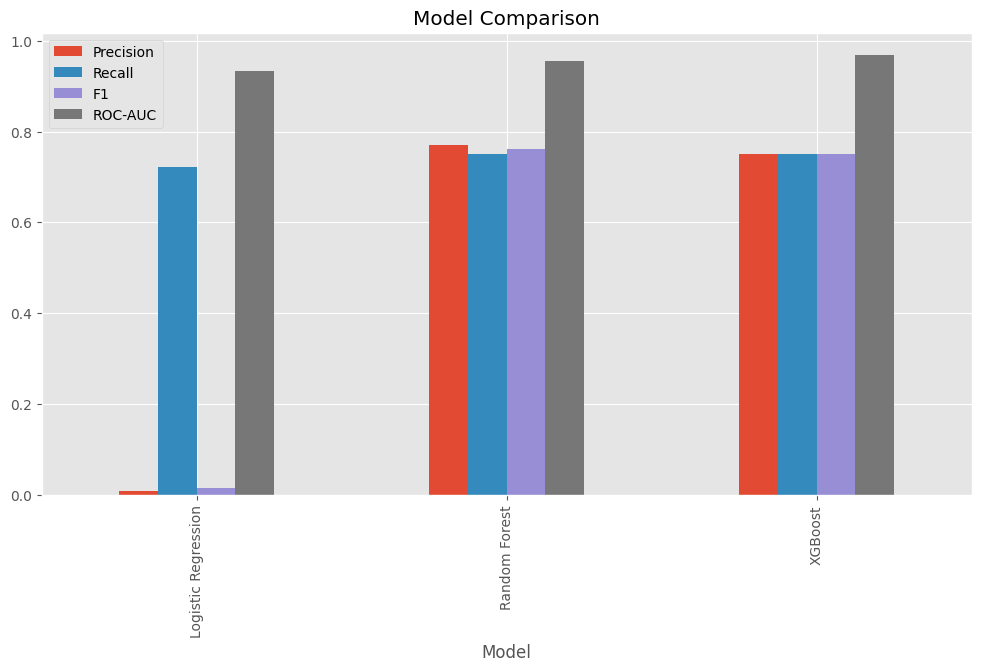

In [ ]:
results.set_index("Model")[

    ["Precision",

     "Recall",

     "F1",

     "ROC-AUC"]

].plot(

    kind="bar",

    figsize=(12,6)

)

plt.title("Model Comparison")

plt.show()

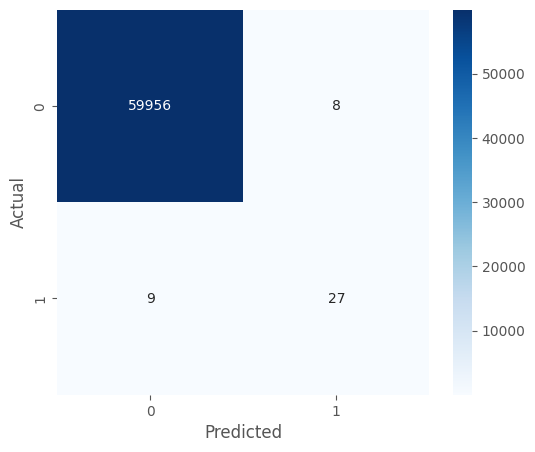

In [ ]:
pred = rf.predict(X_test)

cm = confusion_matrix(

    y_test,

    pred

)

plt.figure(figsize=(6,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [ ]:
print(

classification_report(

    y_test,

    pred

)

)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59964
           1       0.77      0.75      0.76        36

    accuracy                           1.00     60000
   macro avg       0.89      0.87      0.88     60000
weighted avg       1.00      1.00      1.00     60000



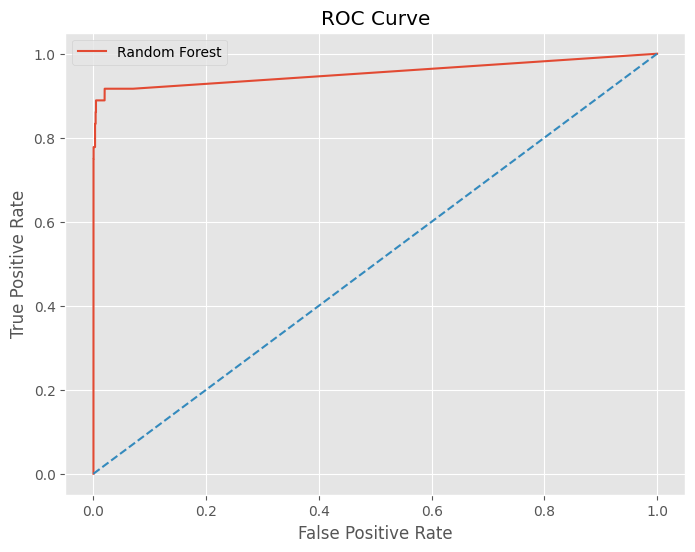

In [ ]:
prob = rf.predict_proba(

    X_test

)[:,1]

fpr,tpr,_ = roc_curve(

    y_test,

    prob

)

plt.figure(figsize=(8,6))

plt.plot(

    fpr,

    tpr,

    label="Random Forest"

)

plt.plot(

    [0,1],

    [0,1],

    "--"

)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

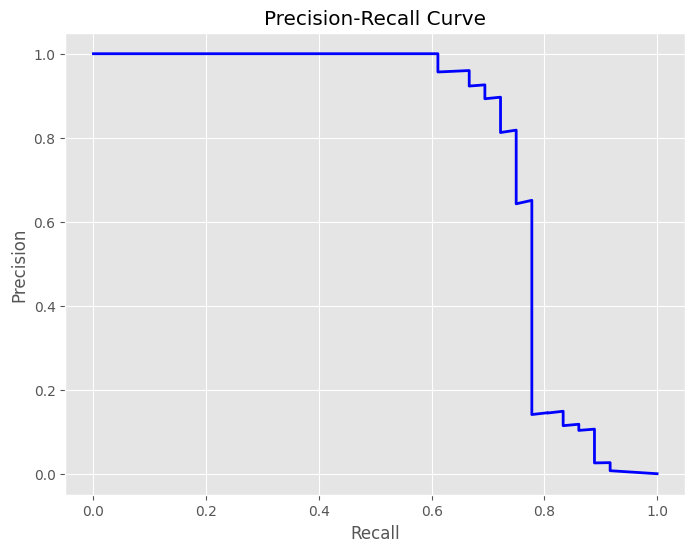

In [ ]:
from sklearn.metrics import precision_recall_curve

precision, recall, thresholds = precision_recall_curve(
    y_test,
    prob
)

plt.figure(figsize=(8,6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    color="blue"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.grid(True)

plt.show()

In [ ]:
importance = pd.DataFrame({

    "Feature":FEATURE_COLUMNS,

    "Importance":rf.feature_importances_

})

importance = importance.sort_values(

    "Importance",

    ascending=False

)

importance

,Feature,Importance
17,balance_usage_percent,0.264792
11,amount_balance_ratio,0.249869
4,newbalanceOrig,0.140923
9,sender_change,0.115158
13,high_balance_usage,0.059229
7,hour,0.035498
0,step,0.027091
3,oldbalanceOrg,0.024624
2,amount,0.016827
14,zero_sender_balance,0.016731


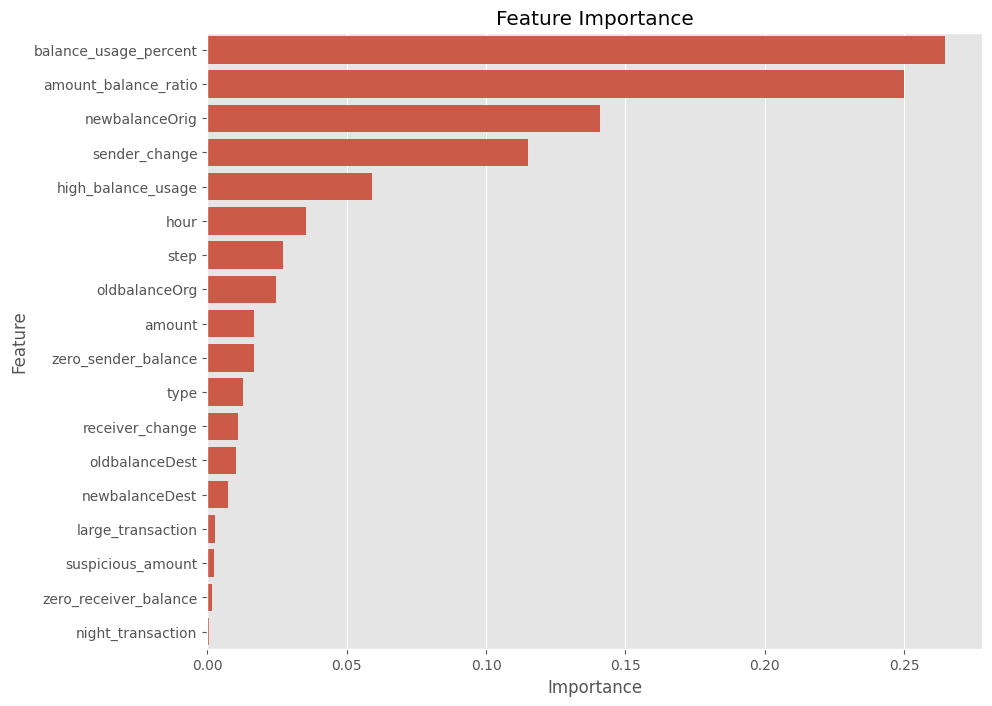

In [ ]:
plt.figure(figsize=(10,8))

sns.barplot(

    data=importance,

    x="Importance",

    y="Feature"

)

plt.title(

    "Feature Importance"

)

plt.show()

In [ ]:
# Probability of Fraud

rf_probability = rf.predict_proba(X_test)[:, 1]

rf_probability[:10]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
# Probability of Fraud

rf_probability = rf.predict_proba(X_test)[:, 1]

rf_probability[:10]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
threshold_results = []

for threshold in thresholds:

    prediction = (rf_probability >= threshold).astype(int)

    precision = precision_score(
        y_test,
        prediction,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        prediction,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        prediction,
        zero_division=0
    )

    threshold_results.append({

        "Threshold": threshold,

        "Precision": precision,

        "Recall": recall,

        "F1": f1

    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results.head()

,Threshold,Precision,Recall,F1
0,0.000000e+00,0.000600,1.000000,0.001199
1,2.626050e-07,0.007772,0.916667,0.015413
2,1.047120e-05,0.013948,0.916667,0.027477
3,2.083333e-05,0.014145,0.916667,0.027860
4,2.631579e-05,0.014298,0.916667,0.028157


In [ ]:
best = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

best

,738
Threshold,0.926610
Precision,0.896552
Recall,0.722222
F1,0.800000


In [ ]:
BEST_THRESHOLD = float(best["Threshold"])

print(BEST_THRESHOLD)

0.9266095238095239


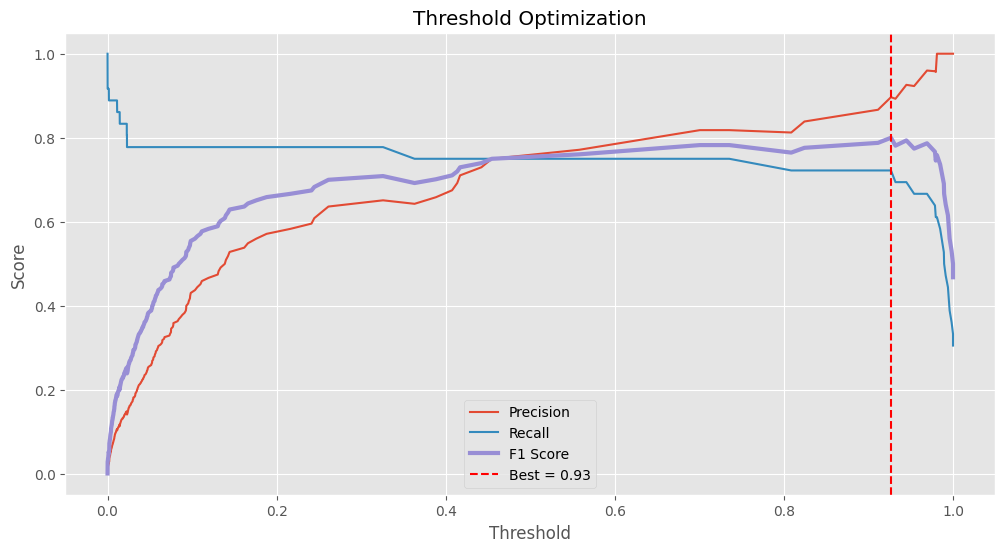

In [ ]:
plt.figure(figsize=(12,6))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    label="F1 Score",
    linewidth=3
)

plt.axvline(
    BEST_THRESHOLD,
    color="red",
    linestyle="--",
    label=f"Best = {BEST_THRESHOLD:.2f}"
)

plt.xlabel("Threshold")

plt.ylabel("Score")

plt.title("Threshold Optimization")

plt.legend()

plt.show()

In [ ]:
prediction = (
    rf_probability >= BEST_THRESHOLD
).astype(int)

print(

classification_report(

    y_test,

    prediction

)

)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     59964
           1       0.90      0.72      0.80        36

    accuracy                           1.00     60000
   macro avg       0.95      0.86      0.90     60000
weighted avg       1.00      1.00      1.00     60000



In [ ]:
joblib.dump(

    rf,

    "fraud_model.pkl"

)

['fraud_model.pkl']

In [ ]:
joblib.dump(

    encoder,

    "label_encoder.pkl"

)

['label_encoder.pkl']

In [ ]:
joblib.dump(

    FEATURE_COLUMNS,

    "feature_columns.pkl"

)

['feature_columns.pkl']

In [ ]:
joblib.dump(

    BEST_THRESHOLD,

    "threshold.pkl"

)

['threshold.pkl']

In [ ]:
import os

files = [

    "fraud_model.pkl",

    "label_encoder.pkl",

    "feature_columns.pkl",

    "threshold.pkl"

]

for file in files:

    print(

        file,

        "✅" if os.path.exists(file) else "❌"

    )

fraud_model.pkl ✅
label_encoder.pkl ✅
feature_columns.pkl ✅
threshold.pkl ✅


In [ ]:
model = joblib.load("fraud_model.pkl")
encoder = joblib.load("label_encoder.pkl")
features = joblib.load("feature_columns.pkl")
threshold = joblib.load("threshold.pkl")

print("Model Loaded Successfully")
print(f"Threshold: {threshold:.2f}")

Model Loaded Successfully
Threshold: 0.93


In [ ]:
sample = {

    "step": 1,

    "type": "TRANSFER",

    "amount": 85000,

    "oldbalanceOrg": 90000,

    "newbalanceOrig": 5000,

    "oldbalanceDest": 0,

    "newbalanceDest": 85000

}

In [ ]:
sample = pd.DataFrame([sample])

sample["type"] = encoder.transform(sample["type"])

sample["hour"] = sample["step"] % 24

sample["night_transaction"] = (
    (sample["hour"] >= 22) |
    (sample["hour"] <= 5)
).astype(int)

sample["sender_change"] = (
    sample["oldbalanceOrg"] -
    sample["newbalanceOrig"]
)

sample["receiver_change"] = (
    sample["newbalanceDest"] -
    sample["oldbalanceDest"]
)

sample["amount_balance_ratio"] = (
    sample["amount"] /
    (sample["oldbalanceOrg"] + 1)
)

sample["large_transaction"] = (
    sample["amount"] > 50000
).astype(int)

sample["high_balance_usage"] = (
    sample["amount_balance_ratio"] > 0.8
).astype(int)

sample["zero_sender_balance"] = (
    sample["oldbalanceOrg"] == 0
).astype(int)

sample["zero_receiver_balance"] = (
    sample["oldbalanceDest"] == 0
).astype(int)

sample["suspicious_amount"] = (
    sample["amount"] > 100000
).astype(int)

sample["balance_usage_percent"] = (
    sample["amount_balance_ratio"] * 100
)

sample = sample[features]

In [ ]:
probability = model.predict_proba(sample)[0][1]

prediction = int(probability >= threshold)

print(f"Fraud Probability : {probability:.4f}")
print(f"Prediction        : {'FRAUD' if prediction else 'SAFE'}")

Fraud Probability : 0.0070
Prediction        : SAFE
